In [1]:
#######
# Function parse_trace_file
#   Wrangle and clean measurement strain data file 
#   Including some mangled data error catching
# Parameters:
#   path - file path to target load cell data (str)
# Returns:
#   Formatted dataframe (pandas Dataframe of form Measurement | Datetime)
#######
import pandas as pd
import os
import warnings

def parse_trace_file(path):
    # Try to parse file
    try:
        # Read original CSV file
        dat = pd.read_csv(path, header=None, names=["Measure", "Datetime"], 
                          encoding="utf-8", encoding_errors="replace", on_bad_lines="skip", 
                          engine="python")
        
        # Convert measurement column to numeric strain values
        dat["Measure"] = pd.to_numeric(dat["Measure"], errors="coerce")            

        # Convert Unix timestamp to datetime
        dat["Datetime"] = pd.to_datetime(dat["Datetime"], unit='s', utc=False, errors="coerce")
        dat["Datetime"] = dat["Datetime"].dt.strftime('%Y-%m-%d %H:%M:%S')

        # We've possibly forced parsing of some malformed data
        #   ("replace" utf-8 encoding errors in read_csv(), "coerce" datetime errors in to_numeric() and to_datetime(), 
        # Now we need to clean that up.
        # Simply drop all points from the file where Measure has been coerced to NaN
        #   and where Datetime has been coerced to NaT
        dat = dat[~dat.Measure.isnull() & ~dat.Datetime.isnull()]
        
        return dat
    
    # Common errors
    except FileNotFoundError:
        warnings.warn("\nInput file not found. FileNotFoundError")
    except pd.errors.EmptyDataError:
        warnings.warn("\nError parsing empty file. EmptyDataError")
    except pd.errors.ParserError:
        warnings.warn("\nError parsing input file. ParserError")
    except Exception as e:
        warnings.warn("\nError parsing input file. {}".format(e))

########
# Load MOM DATA
#######

print(pd.__version__)


#file_path_MOM = "/Users/bobmauck/devel/Testing_Data/DL_06_11_2025_952.TXT"   # get_user_file()# Get user file path
#file_path_MOM = "/Users/bobmauck/devel/Testing_Data/DL_07_09_2025_933.TXT"
file_path_MOM = "/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence/DL260716.TXT"


##filename = os.path.basename(file_path_MOM)
#df_MOM_All = parse_trace_file(file_path_MOM)
# df_MOM_All.head(3)


2.2.2


In [48]:
import pandas as pd

def estimate_hz_v031(df, datetime_col="Datetime", CountN=None):
    """
    v03:
    1) Build a new df with one row per Datetime and the count of lines for that Datetime.
    2) Exclude first and last rows of that grouped df.
    3) For each remaining row, compute:
         hz = lines_in_that_datetime / seconds_to_next_datetime
    4) Return mean hz.
    """
    if datetime_col not in df.columns:
        raise ValueError(f"Missing column: {datetime_col}")

    d = df if CountN is None else df.iloc[:CountN]
    if d.empty:
        raise ValueError("Input DataFrame is empty.")

    # Parse datetime and keep valid rows
    dt = pd.to_datetime(d[datetime_col], errors="coerce")
    valid = pd.DataFrame({"Datetime": dt}).dropna()

    if valid.empty:
        raise ValueError("No valid Datetime values found.")

    # One row per Datetime, with line counts
    per_dt = (
        valid.groupby("Datetime", sort=True)
        .size()
        .reset_index(name="Lines")
    )

    print(f"per_dt length: {len(per_dt)}")

    # Need enough rows after removing first/last
    if len(per_dt) < 4:
        raise ValueError("Need at least 4 unique Datetime values for v03.")

    core = per_dt.iloc[1:-1].copy()  # remove first and last rows
    core["NextDatetime"] = core["Datetime"].shift(-1)
    core["ElapsedSec"] = (core["NextDatetime"] - core["Datetime"]).dt.total_seconds()

    # Last core row has no next row; drop invalid/zero/negative intervals
    core = core.dropna(subset=["ElapsedSec"])
    core = core[core["ElapsedSec"] > 0].copy()

    if core.empty:
        raise ValueError("No positive elapsed intervals available to compute Hz.")

    
    core["Hz"] = core["Lines"] / core["ElapsedSec"]
    mean_hz = core["Hz"].mean()
    STD_hz = core["Hz"].std()

    print(f"Unique datetime (v03): {len(per_dt)}")

    print(f"Mean Hz (v03): {mean_hz:.6f}")
    print(f"STD Hz (v03):  {STD_hz:.6f}")
    return mean_hz, core




In [49]:
#######
# Function estimate_hz_by_row_groups
#   Split a dataframe into groups of CountN rows and estimate Hz for each group.
# Parameters:
#   df - parsed dataframe, e.g. df_MOM_All
#   CountN - number of rows per group
#   datetime_col - timestamp column name
# Returns:
#   pandas Series containing one Hz value per valid group
#######
def estimate_hz_by_row_groups(df, CountN, datetime_col="Datetime"):
    if df is None or df.empty:
        raise ValueError("Input dataframe is empty.")
    if CountN <= 1:
        raise ValueError("CountN must be greater than 1.")
    if datetime_col not in df.columns:
        raise ValueError(f"Missing column: {datetime_col}")

    hz_values = []

    for start_idx in range(0, len(df), CountN):
        group = df.iloc[start_idx:start_idx + CountN].copy()
        if len(group) < CountN:
            continue

        dt = pd.to_datetime(group[datetime_col], errors="coerce").dropna()
        if len(dt) < 2:
            continue

        elapsed_seconds = (dt.iloc[-1] - dt.iloc[0]).total_seconds()
        if elapsed_seconds <= 0:
            continue

        hz_value = CountN / elapsed_seconds
        hz_values.append(hz_value)

    All_Hz_Values = pd.Series(hz_values, name="Hz")
    if All_Hz_Values.empty:
        raise ValueError("No valid Hz groups could be calculated.")

    print(f"All_Hz_Values mean: {All_Hz_Values.mean():.2f}")
    print(f"All_Hz_Values std:  {All_Hz_Values.std():.2f}")

    return All_Hz_Values


In [81]:
# hz = estimate_hz_v02(df_MOM_All)          # whole df
# hz = estimate_hz_v02(df_MOM_All, CountN=10000)  # optional cap

########
# Load MOM DATA
#######

print(pd.__version__)


#file_path_MOM = "/Users/bobmauck/devel/Testing_Data/DL_06_11_2025_952.TXT"   # get_user_file()# Get user file path
#file_path_MOM = "/Users/bobmauck/devel/Testing_Data/DL_07_09_2025_933.TXT"
file_path_MOM = "/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence/DL260716.TXT"


filename = os.path.basename(file_path_MOM)
df_MOM_All = parse_trace_file(file_path_MOM)
# df_MOM_All.head(3)

print("Averaging set at 80, previously was 80")
print('Version 3...')

All_Hz = estimate_hz_by_row_groups(df_MOM_All, CountN=10000)

print(f"All_Hz rows: {len(All_Hz)}")
print(f"CountN: {10000}")

total_rows = len(All_Hz) * 10000
print(f"Total rows represented: {total_rows}")

estimated_mb = total_rows * 20 / 1_000_000
print(f"Estimated file size: {estimated_mb:.2f} MB")

threshold_stats = get_Threshold(df_MOM_All,  doPrint=True)




2.2.2
Averaging set at 80, previously was 80
Version 3...


/var/folders/9v/s975cf3961l3w_3fztmzsv180000gn/T/ipykernel_68152/1529077160.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(group[datetime_col], errors="coerce").dropna()


All_Hz_Values mean: 57.10
All_Hz_Values std:  4.89
All_Hz rows: 373
CountN: 10000
Total rows represented: 3730000
Estimated file size: 74.60 MB
All data:
Rows: 3732300
Mean Measure:    8939594.0
Min Measure:     8866413.0
Max Measure:     9563721.0
STD Measure:     9331.9
Std Error:       4.8
Max/STD:         1024.842
First 10 minutes:
Start: 2026-07-16 09:17:45
End:   2026-07-16 09:27:45
Rows: 32100
Mean Measure:    8945476.3
Min Measure:     8932928.0
Max Measure:     9453880.0
STD Measure:     40300.4
Std Error:       224.9
Max/STD:         234.585
Night rows, time > 19:00 or < 06:00:
Rows: 2256900
Mean Measure:    8939093.6
Min Measure:     8919468.0
Max Measure:     9563721.0
STD Measure:     5449.2
Std Error:       3.6
Max/STD:         1755.063


In [2]:
#######
# Function get_Threshold
#   Compute summary statistics for df["Measure"].
#   Also compute the same statistics for the first 10 minutes of data
#   and for nighttime rows where time > 19:00 or time < 06:00.
# Parameters:
#   df - parsed dataframe, e.g. df_MOM_All
#   doPrint - print stats when True; default False
# Returns:
#   dict with full, first-10-minute, and nighttime threshold stats
#######
def get_Threshold(df, doPrint=False):
    def _parse_datetime_series(series):
        numeric = pd.to_numeric(series, errors="coerce")
        if numeric.notna().sum() >= series.notna().sum() * 0.8:
            return pd.to_datetime(numeric, unit="s", errors="coerce")
        return pd.to_datetime(series, format="%Y-%m-%d %H:%M:%S", errors="coerce")

    if df is None or df.empty:
        raise ValueError("Input dataframe is empty.")
    if "Measure" not in df.columns:
        raise ValueError("Dataframe must contain a Measure column.")
    if "Datetime" not in df.columns:
        raise ValueError("Dataframe must contain a Datetime column for time-based stats.")

    def _measure_stats(series, allow_empty=False):
        measure = pd.to_numeric(series, errors="coerce").dropna()
        if measure.empty:
            if allow_empty:
                return 0, float("nan"), float("nan"), float("nan"), float("nan"), float("nan"), float("nan")
            raise ValueError("No numeric Measure values found in dataframe.")

        rows = len(measure)
        mean_measure = measure.mean()
        min_measure = measure.min()
        max_measure = measure.max()
        std_measure = measure.std()
        sterror_measure = std_measure / (rows ** 0.5)
        max_std_measure = max_measure / std_measure if pd.notna(std_measure) and std_measure != 0 else float("nan")

        return rows, mean_measure, min_measure, max_measure, std_measure, sterror_measure, max_std_measure

    rows, mean_measure, min_measure, max_measure, std_measure, sterror_measure, max_std = _measure_stats(df["Measure"])

    dt = _parse_datetime_series(df["Datetime"])
    valid_dt = dt.dropna()
    if valid_dt.empty:
        raise ValueError("No valid Datetime values found for time-based stats.")

    start_time = valid_dt.iloc[0]
    end_10 = start_time + pd.Timedelta(minutes=10)
    first_10_mask = (dt >= start_time) & (dt < end_10)
    rows_10, mean_10, min_10, max_10, std_10, sterror_10, max_std_10 = _measure_stats(df.loc[first_10_mask, "Measure"])

    seconds_of_day = dt.dt.hour * 3600 + dt.dt.minute * 60 + dt.dt.second
    night_mask = (seconds_of_day > 19 * 3600) | (seconds_of_day < 6 * 3600)
    rows_night, mean_night, min_night, max_night, std_night, sterror_night, max_std_night = _measure_stats(
        df.loc[night_mask, "Measure"], allow_empty=True
    )

    if doPrint:
        print("All data:")
        print(f"Rows: {rows}")
        print(f"Mean Measure:    {mean_measure:.1f}")
        print(f"Min Measure:     {min_measure:.1f}")
        print(f"Max Measure:     {max_measure:.1f}")
        print(f"STD Measure:     {std_measure:.1f}")
        print(f"Std Error:       {sterror_measure:.1f}")
        print(f"Max/STD:         {max_std:.3f}")
        print("First 10 minutes:")
        print(f"Start: {start_time}")
        print(f"End:   {end_10}")
        print(f"Rows: {rows_10}")
        print(f"Mean Measure:    {mean_10:.1f}")
        print(f"Min Measure:     {min_10:.1f}")
        print(f"Max Measure:     {max_10:.1f}")
        print(f"STD Measure:     {std_10:.1f}")
        print(f"Std Error:       {sterror_10:.1f}")
        print(f"Max/STD:         {max_std_10:.3f}")
        print("Night rows, time > 19:00 or < 06:00:")
        print(f"Rows: {rows_night}")
        print(f"Mean Measure:    {mean_night:.1f}")
        print(f"Min Measure:     {min_night:.1f}")
        print(f"Max Measure:     {max_night:.1f}")
        print(f"STD Measure:     {std_night:.1f}")
        print(f"Std Error:       {sterror_night:.1f}")
        print(f"Max/STD:         {max_std_night:.3f}")

    return {
        "rows": rows, "mean": mean_measure, "min": min_measure, "max": max_measure,
        "std": std_measure,  "Max/STD": max_std,
        "rows_10": rows_10, "mean_10": mean_10, "min_10": min_10, "max_10": max_10,
        "std_10": std_10, "Max/STD_10": max_std_10,
        "rows_night": rows_night, "mean_night": mean_night, "min_night": min_night,
        "max_night": max_night, "std_night": std_night, 
        "Max/STD_night": max_std_night,
    }


In [3]:
#######
# Function examine_files_threshold
#   Find DL*.txt files in a folder, run get_Threshold() on each,
#   and display/return one dataframe of threshold statistics.
# Parameters:
#   folder_path - path to folder containing DL*.TXT files
# Returns:
#   thresholds_txt dataframe
#######
def examine_files_threshold(folder_path):
    from pathlib import Path

    folder = Path(folder_path).expanduser()
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    if not folder.is_dir():
        raise NotADirectoryError(f"Not a folder: {folder}")

    files = sorted(
        p for p in folder.iterdir()
        if p.is_file()
        and p.name.lower().startswith("dl")
        and p.name.lower().endswith(".txt")
    )

    rows = []
    for file_path in files:
        print(f"\nProcessing: {file_path.name}")
        df = parse_trace_file(str(file_path))
        stats = get_Threshold(df)
        stats["filename"] = file_path.name
        stats["path"] = str(file_path)
        rows.append(stats)

    thresholds_txt = pd.DataFrame(rows)
    if not thresholds_txt.empty:
        first_cols = ["filename", "path"]
        other_cols = [c for c in thresholds_txt.columns if c not in first_cols]
        thresholds_txt = thresholds_txt[first_cols + other_cols]

    try:
        display(thresholds_txt)
    except NameError:
        print(thresholds_txt)

    return thresholds_txt


In [ ]:
# get multiple files

# thresholds_txt = examine_files_threshold("/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence")

# thresholds_txt = examine_files_threshold("/Users/robertmauck/Dropbox/BIG_Science/MOMs/MOMs_Software/COMBO_Viewer/Testing_Data")

thresholds_txt = examine_files_threshold("/Users/robertmauck/Dropbox/BIG_Science/2026_Summer/Test_Data") #

thresholds_txt.to_csv(
    "/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence/thresholds_txt_02.txt",
    sep="\t",
    index=False,
    float_format="%.1f"
)



#thresholds_txt = examine_files_threshold("/Users/robertmauck/Dropbox/BIG_Science/MOMs/Testing/KI_2024/Validation_07_07/DL_Files")



Processing: DL_06_29_2026_380.TXT

Processing: DL_06_29_2026_382.TXT

Processing: DL_06_29_2026_931.txt

Processing: DL_06_29_2026_933.TXT

Processing: DL_06_29_2026_945.TXT

Processing: DL_06_29_2026_952.txt

Processing: DL_06_29_2026_968.txt

Processing: DL_06_29_2026_969.TXT

Processing: DL_06_29_v2_2026_372.TXT

Processing: DL_06_30-07_01_2026_18.txt

Processing: DL_06_30-07_01_2026_222.TXT

Processing: DL_06_30-07_01_2026_267.TXT

Processing: DL_06_30-07_01_2026_365.TXT

Processing: DL_06_30-07_01_2026_367.TXT

Processing: DL_06_30-07_01_2026_380.txt

Processing: DL_06_30-07_01_2026_931.txt

Processing: DL_06_30-07_01_2026_968.txt

Processing: DL_06_30-07_01_2026_969.TXT

Processing: DL_06_30-07_01_2026_97.txt

Processing: DL_06_30_2026_20.txt

Processing: DL_06_30_2026_217.txt

Processing: DL_06_30_2026_219.TXT

Processing: DL_06_30_2026_230.txt

Processing: DL_06_30_2026_235.txt

Processing: DL_06_30_2026_349.txt

Processing: DL_06_30_2026_352.TXT

Processing: DL_06_30_2026_359

,filename,path,rows,mean,min,max,std,Max/STD,rows_10,mean_10,min_10,max_10,std_10,Max/STD_10,rows_night,mean_night,min_night,max_night,std_night,Max/STD_night
0,DL_06_29_2026_380.TXT,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4819200,8.496738e+06,8479287,8777140,4168.571005,2105.551276,33900,8.498978e+06,8491890,8717064,15053.863563,579.058257,2257800,8.496867e+06,8479287.0,8601959.0,5410.120955,1589.975358
1,DL_06_29_2026_382.TXT,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4751700,6.704487e+06,6682794,7468978,2863.648953,2608.203073,33900,6.709346e+06,6704468,7468978,21919.076377,340.752405,2229600,6.703322e+06,6682794.0,6796277.0,1299.298267,5230.728903
2,DL_06_29_2026_931.txt,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4763400,8.247914e+06,8215984,8625807,11080.411767,778.473506,33900,8.268064e+06,8251051,8625807,21021.298323,410.336549,2253900,8.242373e+06,8215984.0,8322335.0,6737.539676,1235.218700
3,DL_06_29_2026_933.TXT,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4683300,8.935145e+06,8915493,9125176,2460.396250,3708.823732,33900,8.939287e+06,8915493,9120881,17690.418675,515.583106,2237400,8.934843e+06,8933573.0,8935818.0,427.810752,20887.315131
4,DL_06_29_2026_945.TXT,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4810200,8.844418e+06,8795243,9364623,2170.530475,4314.439769,33600,8.848041e+06,8830352,9364623,18368.074772,509.831494,2232000,8.844905e+06,8843380.0,8847000.0,189.888793,46590.427203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,DL_07_02_2026_379.txt,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,5006700,7.557919e+06,7555522,7909732,2074.590150,3812.672108,34200,7.560083e+06,7555796,7905773,15326.358011,515.828548,2343600,7.558072e+06,7555522.0,7909732.0,3006.291286,2631.059750
74,DL_07_02_2026_380.txt,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4686000,8.497680e+06,8491026,8863245,1981.291102,4473.469341,33900,8.499925e+06,8491026,8824738,14785.740962,596.841107,2257500,8.497500e+06,8496916.0,8498115.0,89.709911,94728.831319
75,DL_07_02_2026_382.TXT,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,4980900,6.704319e+06,6657348,7257448,2815.033878,2578.103253,33900,6.709126e+06,6675588,7257448,24774.212729,292.943638,2231700,6.703385e+06,6702395.0,6704391.0,236.843144,28307.304546
76,DL_07_02_2026_87.txt,/Users/robertmauck/Dropbox/BIG_Science/2026_Su...,5036100,6.701393e+06,6677616,6966153,1909.158893,3648.807349,34200,6.703456e+06,6677616,6966153,13972.401290,498.565197,2249400,6.700693e+06,6699845.0,6701797.0,239.119364,28026.994128


In [ ]:
thresholds_txt.to_csv(
    "/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence/thresholds_txt_02.txt",
    sep="\t",
    index=False,
    float_format="%.1f"
)


In [4]:
#######
# Function trim_dl_file_to_evidence
#   Python version of the simplified Arduino TRIM sketch logic.
#   Takes one DL*.TXT file, derives calibration thresholds, builds trim intervals,
#   and writes the matching TR*.TXT file into the Evidence folder.
#   Optionally plots the DL file on the top panel and the TR file on the bottom.
# Parameters:
#   dl_path - path to a DL*.TXT file
#   evidence_folder - output folder; default is ./Evidence
#   force_retrim - overwrite existing TR file when True
#   doPlot - display DL/TR comparison plot when True
#   max_plot_points - maximum points per panel for plotting only; None plots every point
# Returns:
#   dict with trim status, thresholds, interval count, row counts, and output path
#######
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt

TRIM_CALIBRATION_SECONDS = 600
TRIM_FALLBACK_SECONDS = 60
TRIM_START_GUARD_SECONDS = TRIM_CALIBRATION_SECONDS
TRIM_PRE_EVENT_SECONDS = 180
TRIM_POST_EVENT_SECONDS = 600
TRIM_DEBOUNCE_SECONDS = 0.5
TRIM_PROGRESS_ROWS = 50000
MAX_TRIM_INTERVALS = 128

TRIM_CAL_BUCKET_SAMPLES = 60
TRIM_CAL_BUCKET_MIN_SAMPLES = 30
TRIM_CAL_BASELINE_LOWEST_FRACTION = 0.20
TRIM_CAL_STEADY_SD_MULTIPLIER = 4.0
TRIM_CAL_BASELINE_SEPARATION_SD = 8.0
TRIM_CAL_BASELINE_BUCKET_MAX = 160


def plot_dl_tr_files(dl_path, tr_path, max_points=None):
    dl_path = Path(dl_path).expanduser()
    tr_path = Path(tr_path).expanduser()

    def _load_plot_df(path):
        df = pd.read_csv(
            path,
            header=None,
            names=["Measure", "Datetime"],
            encoding="utf-8",
            encoding_errors="replace",
            on_bad_lines="skip",
            engine="python",
        )
        df["Measure"] = pd.to_numeric(df["Measure"], errors="coerce")
        numeric_dt = pd.to_numeric(df["Datetime"], errors="coerce")
        df["Datetime"] = pd.to_datetime(numeric_dt, unit="s", errors="coerce")
        df = df.dropna(subset=["Measure", "Datetime"])
        original_rows = len(df)
        if max_points is not None and max_points > 0 and len(df) > max_points:
            step = math.ceil(len(df) / max_points)
            df = df.iloc[::step].copy()
        else:
            step = 1
        return df, original_rows, step

    dl_df, dl_rows, dl_step = _load_plot_df(dl_path)
    tr_df, tr_rows, tr_step = _load_plot_df(tr_path)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    axes[0].plot(dl_df["Datetime"], dl_df["Measure"], linewidth=0.7)
    axes[0].set_title(f"DL raw: {dl_path.name} ({dl_rows:,} rows, plot step {dl_step})")
    axes[0].set_ylabel("Measure")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(tr_df["Datetime"], tr_df["Measure"], linewidth=0.7)
    axes[1].set_title(f"TR trimmed: {tr_path.name} ({tr_rows:,} rows, plot step {tr_step})")
    axes[1].set_ylabel("Measure")
    axes[1].set_xlabel("Datetime")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()
    return fig, axes


def trim_dl_file_to_evidence(dl_path, evidence_folder="Evidence", force_retrim=True, doPlot=True, max_plot_points=None):
    dl_path = Path(dl_path).expanduser()
    evidence_folder = Path(evidence_folder).expanduser()
    evidence_folder.mkdir(parents=True, exist_ok=True)

    raw_name = dl_path.name
    raw_upper = raw_name.upper()
    if not raw_upper.startswith("DL") or not raw_upper.endswith(".TXT"):
        raise ValueError(f"Input file must start with DL and end with .TXT: {raw_name}")
    if not dl_path.exists():
        raise FileNotFoundError(f"Input file not found: {dl_path}")
    if not dl_path.is_file():
        raise ValueError(f"Input path is not a file: {dl_path}")

    trim_name = "TR" + raw_name[2:]
    output_path = evidence_folder / trim_name

    if output_path.exists() and not force_retrim:
        print(f"TRIM skip existing: {output_path}")
        if doPlot:
            plot_dl_tr_files(dl_path, output_path, max_points=max_plot_points)
        return {
            "ok": True,
            "skipped": True,
            "raw_path": str(dl_path),
            "output_path": str(output_path),
        }

    if dl_path.stat().st_size == 0:
        print(f"TRIM skip empty raw: {dl_path}")
        return {
            "ok": False,
            "skipped": False,
            "reason": "EMPTY_RAW",
            "raw_path": str(dl_path),
            "output_path": str(output_path),
        }

    def _read_data_lines(file_path):
        with file_path.open("r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.rstrip("\r\n \t")
                if line:
                    yield line

    def _parse_data_csv_line(line):
        if "," not in line:
            return None
        left, right = line.split(",", 1)
        left = left.strip()
        right = right.strip()
        try:
            value = int(left)
            ts = int(right)
        except ValueError:
            return None
        if ts == 0:
            return None
        return value, ts

    def _sample_sd(n, mean, m2):
        return math.sqrt(m2 / (n - 1)) if n > 1 else 0.0

    def _derive_calibration_thresholds_from_file(input_path):
        have_first = False
        cal_min = 0
        cal_max = 0
        first_ts = 0
        bucket_count = 0
        bucket_n = 0

        for line in _read_data_lines(input_path):
            parsed = _parse_data_csv_line(line)
            if parsed is None:
                continue
            value, ts = parsed
            if not have_first:
                have_first = True
                first_ts = ts
                cal_min = value
                cal_max = value
            if ts > first_ts + TRIM_CALIBRATION_SECONDS:
                break
            if value < cal_min:
                cal_min = value
            if value > cal_max:
                cal_max = value
            bucket_n += 1
            if bucket_n >= TRIM_CAL_BUCKET_SAMPLES:
                bucket_count += 1
                bucket_n = 0

        if bucket_n >= TRIM_CAL_BUCKET_MIN_SAMPLES:
            bucket_count += 1
        if not have_first or bucket_count == 0:
            return {"ok": False}

        baseline_keep = int(bucket_count * TRIM_CAL_BASELINE_LOWEST_FRACTION)
        if baseline_keep < 3:
            baseline_keep = 3
        if baseline_keep > TRIM_CAL_BASELINE_BUCKET_MAX:
            baseline_keep = TRIM_CAL_BASELINE_BUCKET_MAX

        low_means = []
        low_sds = []
        bucket_n = 0
        bucket_mean = 0.0
        bucket_m2 = 0.0

        def finish_baseline_bucket():
            nonlocal bucket_n, bucket_mean, bucket_m2, low_means, low_sds
            if bucket_n < TRIM_CAL_BUCKET_MIN_SAMPLES:
                bucket_n = 0
                bucket_mean = 0.0
                bucket_m2 = 0.0
                return

            m = int(bucket_mean)
            sd = _sample_sd(bucket_n, bucket_mean, bucket_m2)
            if len(low_means) < baseline_keep:
                low_means.append(m)
                low_sds.append(sd)
            else:
                max_idx = max(range(len(low_means)), key=lambda i: low_means[i])
                if m < low_means[max_idx]:
                    low_means[max_idx] = m
                    low_sds[max_idx] = sd

            bucket_n = 0
            bucket_mean = 0.0
            bucket_m2 = 0.0

        for line in _read_data_lines(input_path):
            parsed = _parse_data_csv_line(line)
            if parsed is None:
                continue
            value, ts = parsed
            if ts > first_ts + TRIM_CALIBRATION_SECONDS:
                break

            bucket_n += 1
            delta = value - bucket_mean
            bucket_mean += delta / bucket_n
            bucket_m2 += delta * (value - bucket_mean)
            if bucket_n >= TRIM_CAL_BUCKET_SAMPLES:
                finish_baseline_bucket()
        finish_baseline_bucket()

        low_count = len(low_means)
        if low_count < 2:
            return {"ok": False}

        low_means_sorted = sorted(low_means)
        baseline = low_means_sorted[low_count // 2]
        if low_count % 2 == 0 and low_count >= 2:
            baseline = int((low_means_sorted[(low_count // 2) - 1] + low_means_sorted[low_count // 2]) / 2)

        low_sds_sorted = sorted(low_sds)
        baseline_sd = low_sds_sorted[low_count // 2]
        if low_count % 2 == 0 and low_count >= 2:
            baseline_sd = (low_sds_sorted[(low_count // 2) - 1] + low_sds_sorted[low_count // 2]) / 2.0
        if baseline_sd <= 0.0:
            baseline_sd = 1.0

        steady_sd_limit = baseline_sd * TRIM_CAL_STEADY_SD_MULTIPLIER
        if steady_sd_limit < baseline_sd + 1.0:
            steady_sd_limit = baseline_sd + 1.0
        above_baseline_min = baseline + baseline_sd * TRIM_CAL_BASELINE_SEPARATION_SD
        if above_baseline_min < baseline + 1.0:
            above_baseline_min = baseline + 1.0

        low_mean = None
        bucket_n = 0
        bucket_mean = 0.0
        bucket_m2 = 0.0

        def finish_low_bucket():
            nonlocal bucket_n, bucket_mean, bucket_m2, low_mean
            if bucket_n < TRIM_CAL_BUCKET_MIN_SAMPLES:
                bucket_n = 0
                bucket_mean = 0.0
                bucket_m2 = 0.0
                return

            m = int(bucket_mean)
            sd = _sample_sd(bucket_n, bucket_mean, bucket_m2)
            if sd <= steady_sd_limit and m > above_baseline_min and (low_mean is None or m < low_mean):
                low_mean = m

            bucket_n = 0
            bucket_mean = 0.0
            bucket_m2 = 0.0

        for line in _read_data_lines(input_path):
            parsed = _parse_data_csv_line(line)
            if parsed is None:
                continue
            value, ts = parsed
            if ts > first_ts + TRIM_CALIBRATION_SECONDS:
                break

            bucket_n += 1
            delta = value - bucket_mean
            bucket_mean += delta / bucket_n
            bucket_m2 += delta * (value - bucket_mean)
            if bucket_n >= TRIM_CAL_BUCKET_SAMPLES:
                finish_low_bucket()
        finish_low_bucket()

        if low_mean is None or low_mean < cal_min or low_mean > cal_max:
            return {"ok": False}

        return {
            "ok": True,
            "firstTs": first_ts,
            "baselineMean": baseline,
            "lowCalibrationMean": low_mean,
            "enterThreshold": low_mean,
            "exitThreshold": low_mean,
        }

    def _add_trim_interval(intervals, start_ts, end_ts):
        if end_ts <= start_ts:
            return
        if not intervals:
            intervals.append([start_ts, end_ts])
            return
        last = intervals[-1]
        if start_ts <= last[1]:
            if end_ts > last[1]:
                last[1] = end_ts
            return
        if len(intervals) >= MAX_TRIM_INTERVALS:
            if end_ts > last[1]:
                last[1] = end_ts
            return
        intervals.append([start_ts, end_ts])

    def _build_trim_intervals_for_file(input_path, cal):
        intervals = []
        first_ts = 0
        last_ts = 0
        have_first = False
        event_latched = False
        capture_active = False
        capture_until = 0
        current_capture_start = 0
        above_since = 0
        below_since = 0
        parsed_rows = 0
        next_progress = TRIM_PROGRESS_ROWS
        debounce_whole_seconds = int(TRIM_DEBOUNCE_SECONDS)

        for line in _read_data_lines(input_path):
            parsed = _parse_data_csv_line(line)
            if parsed is None:
                continue
            value, ts = parsed
            parsed_rows += 1
            if not have_first:
                have_first = True
                first_ts = ts
                _add_trim_interval(intervals, first_ts, first_ts + TRIM_CALIBRATION_SECONDS)
            last_ts = ts

            if ts <= first_ts + TRIM_CALIBRATION_SECONDS:
                continue
            if ts < first_ts + TRIM_START_GUARD_SECONDS:
                continue

            if value >= cal["enterThreshold"]:
                if above_since == 0:
                    above_since = ts
                below_since = 0
            elif value <= cal["exitThreshold"]:
                if below_since == 0:
                    below_since = ts
                above_since = 0
            else:
                above_since = 0
                below_since = 0

            if (not event_latched) and above_since != 0 and (ts - above_since) >= debounce_whole_seconds:
                event_latched = True
                pre_start = ts - TRIM_PRE_EVENT_SECONDS if ts > TRIM_PRE_EVENT_SECONDS else first_ts
                if pre_start < first_ts:
                    pre_start = first_ts
                if not capture_active:
                    capture_active = True
                    current_capture_start = pre_start
                elif pre_start < current_capture_start:
                    current_capture_start = pre_start
                capture_until = ts + TRIM_POST_EVENT_SECONDS
                above_since = 0

            if event_latched and below_since != 0 and (ts - below_since) >= debounce_whole_seconds:
                event_latched = False
                below_since = 0

            if capture_active and (not event_latched) and ts >= capture_until:
                _add_trim_interval(intervals, current_capture_start, capture_until)
                capture_active = False

            if parsed_rows >= next_progress:
                print(f"TRIM analyze rows={parsed_rows} intervals={len(intervals)}")
                next_progress += TRIM_PROGRESS_ROWS

        if not have_first:
            return None, parsed_rows
        if capture_active:
            end_ts = capture_until if last_ts > capture_until else last_ts
            _add_trim_interval(intervals, current_capture_start, end_ts)
        return intervals, parsed_rows

    def _write_trimmed_file_from_intervals(input_path, output_path, intervals):
        total = 0
        kept = 0
        idx = 0
        next_progress = TRIM_PROGRESS_ROWS

        with input_path.open("r", encoding="utf-8", errors="replace") as infile, output_path.open("w", encoding="utf-8") as outfile:
            for raw_line in infile:
                line = raw_line.rstrip("\r\n \t")
                if not line:
                    continue
                parsed = _parse_data_csv_line(line)
                if parsed is None:
                    continue
                value, ts = parsed
                total += 1
                while idx < len(intervals) and ts > intervals[idx][1]:
                    idx += 1
                if idx < len(intervals) and ts >= intervals[idx][0] and ts <= intervals[idx][1]:
                    outfile.write(line + "\n")
                    kept += 1
                if total >= next_progress:
                    print(f"TRIM write rows={total} kept={kept}")
                    next_progress += TRIM_PROGRESS_ROWS

        print(f"TRIM done rows={total} kept={kept}")
        return total, kept

    def _write_trim_fallback_calibration_only(input_path, output_path):
        total = 0
        kept = 0
        first_ts = 0
        have_first = False

        with input_path.open("r", encoding="utf-8", errors="replace") as infile, output_path.open("w", encoding="utf-8") as outfile:
            for raw_line in infile:
                line = raw_line.rstrip("\r\n \t")
                if not line:
                    continue
                parsed = _parse_data_csv_line(line)
                if parsed is None:
                    continue
                value, ts = parsed
                total += 1
                if not have_first:
                    have_first = True
                    first_ts = ts
                if ts > first_ts + TRIM_FALLBACK_SECONDS:
                    break
                outfile.write(line + "\n")
                kept += 1

        print(f"TRIM fallback rows={total} kept={kept}")
        return total, kept

    print(f"TRIM start raw={dl_path.name} out={output_path.name}")

    cal = _derive_calibration_thresholds_from_file(dl_path)
    if not cal["ok"]:
        print("TRIM calibration threshold failed; writing fallback")
        total, kept = _write_trim_fallback_calibration_only(dl_path, output_path)
        if doPlot and kept > 0:
            plot_dl_tr_files(dl_path, output_path, max_points=max_plot_points)
        return {
            "ok": kept > 0,
            "fallback": True,
            "raw_path": str(dl_path),
            "output_path": str(output_path),
            "total_rows": total,
            "kept_rows": kept,
        }

    print(f"TRIM thresholds baseline={cal['baselineMean']} low={cal['lowCalibrationMean']}")

    intervals, parsed_rows = _build_trim_intervals_for_file(dl_path, cal)
    if intervals is None:
        print("TRIM fail: interval build")
        return {
            "ok": False,
            "fallback": False,
            "reason": "INTERVAL_BUILD_FAILED",
            "raw_path": str(dl_path),
            "output_path": str(output_path),
        }

    print(f"TRIM intervals={len(intervals)}")
    total, kept = _write_trimmed_file_from_intervals(dl_path, output_path, intervals)
    print(f"TRIM complete: {output_path}")
    if doPlot:
        plot_dl_tr_files(dl_path, output_path, max_points=max_plot_points)

    return {
        "ok": True,
        "fallback": False,
        "raw_path": str(dl_path),
        "output_path": str(output_path),
        "baselineMean": cal["baselineMean"],
        "lowCalibrationMean": cal["lowCalibrationMean"],
        "enterThreshold": cal["enterThreshold"],
        "exitThreshold": cal["exitThreshold"],
        "interval_count": len(intervals),
        "intervals": intervals,
        "total_rows": total,
        "kept_rows": kept,
        "parsed_rows": parsed_rows,
    }


TRIM start raw=DL_06_29_2026_931.TXT out=TR_06_29_2026_931.TXT
TRIM thresholds baseline=8263891 low=8264349
TRIM analyze rows=50000 intervals=1
TRIM analyze rows=100000 intervals=1
TRIM analyze rows=150000 intervals=1
TRIM analyze rows=200000 intervals=1
TRIM analyze rows=250000 intervals=1
TRIM analyze rows=300000 intervals=1
TRIM analyze rows=350000 intervals=1
TRIM analyze rows=400000 intervals=1
TRIM analyze rows=450000 intervals=1
TRIM analyze rows=500000 intervals=1
TRIM analyze rows=550000 intervals=1
TRIM analyze rows=600000 intervals=1
TRIM analyze rows=650000 intervals=2
TRIM analyze rows=700000 intervals=3
TRIM analyze rows=750000 intervals=3
TRIM analyze rows=800000 intervals=3
TRIM analyze rows=850000 intervals=3
TRIM analyze rows=900000 intervals=3
TRIM analyze rows=950000 intervals=4
TRIM analyze rows=1000000 intervals=4
TRIM analyze rows=1050000 intervals=5
TRIM analyze rows=1100000 intervals=6
TRIM analyze rows=1150000 intervals=6
TRIM analyze rows=1200000 intervals=6


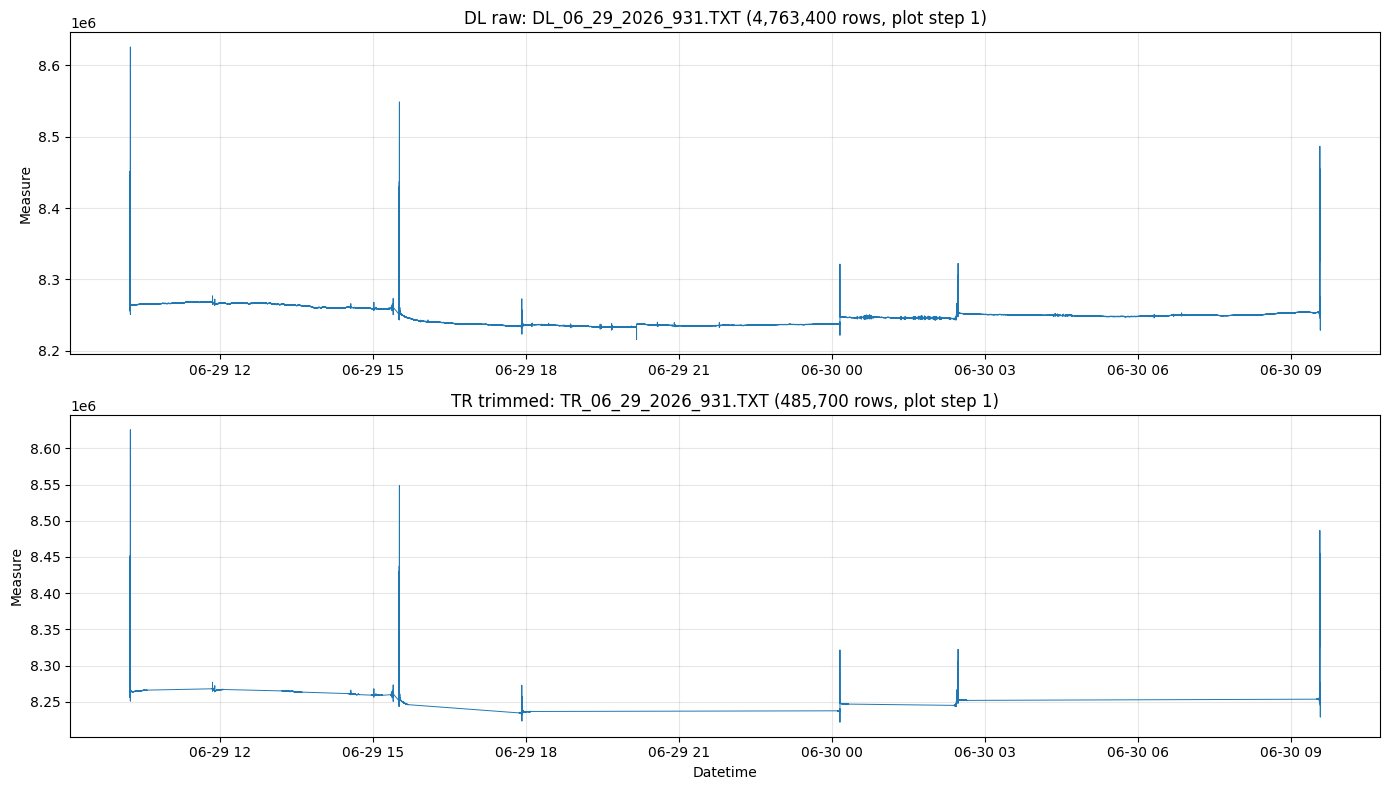

In [12]:
result = trim_dl_file_to_evidence(
    # this works fine "/Users/robertmauck/Documents/devel/Arduino_WIFI/Evidence/DL260716.TXT"
    # missed one "/Users/robertmauck/Dropbox/BIG_Science/2026_Summer/Test_Data/DL_06_29_2026_380.TXT"
    # this works fine"/Users/robertmauck/Dropbox/BIG_Science/2026_Summer/Test_Data/DL_06_29_2026_382.TXT"
    "/Users/robertmauck/Dropbox/BIG_Science/2026_Summer/Test_Data/DL_06_29_2026_931.TXT"
) 